<a href="https://colab.research.google.com/github/ParkHangah/AIFFEL_quest_eng/blob/master/LLM_Aplication/LLM01/D041_LLM_nd2_Seq2seq%EB%B2%88%EC%97%AD%EA%B8%B0%EB%A7%8C%EB%93%A4%EA%B8%B0_vr0_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Seq2seq번역기만들기**

# 0. 사전준비

- T4 메모리인경우 검증에서 학습이 멈추는 현상이 발생
- 코랩 유료버전, 런타임 유형을 GPU A100 선택을 추천

| 하드웨어 | 예상 메모리 (GB) | 주요 용도 및 특징 |
|---|---|---|
| **CPU** | 시스템 RAM 공유 | 기본적인 연산, 소규모 데이터 처리, GPU가 필요 없는 작업, 디버깅 |
| **H100 GPU** | 80 (고성능) | 최신 및 최고 성능의 GPU. 대규모 언어 모델(LLM), 복잡한 AI 모델 훈련, 고성능 컴퓨팅(HPC)에 최적화. Colab Enterprise에서 사용 가능성 높음. |
| **G4 GPU** | 16/24 (T4와 유사) | Colab에서 'GPU' 런타임으로 간헐적으로 제공될 수 있는 범용 GPU. T4와 유사한 워크로드에 적합. |
| **A100 GPU** | 40/80 (고성능) | LLM, Transformer 기반 모델, 대규모 딥러닝 모델 훈련 및 추론에 탁월. Colab Pro/Pro+에서 접근 가능성이 높음. |
| **L4 GPU** | 24 (중급) | 비교적 최신 GPU로, T4보다 개선된 성능을 제공. 합리적인 가격으로 딥러닝 훈련 및 추론에 적합. Colab에서 'A100/V100' 선택 시 간헐적으로 제공될 수 있음. |
| **T4 GPU** | 16 (표준) | Colab 무료 및 Pro/Pro+의 기본 GPU. 일반적인 딥러닝 모델 훈련 및 추론, 데이터 과학 작업에 널리 사용. 비용 효율적. |
| **v6e-1 TPU** | 16 (TPU 메모리) | Google Cloud TPU v5e 아키텍처 기반의 텐서 처리 장치. 배치 크기가 크고 행렬 연산이 많은 딥러닝 모델(특히 Transformer, ResNet 등) 훈련에 매우 효율적. Colab Enterprise에서 사용 가능성 높음. |
| **v5e-1 TPU** | 16 (TPU 메모리) | Google Cloud TPU v5e 아키텍처 기반의 텐서 처리 장치. 주로 텐서 연산 가속에 특화되어 대규모 딥러닝 모델 훈련에 적합. Colab Enterprise에서 사용 가능성 높음. |

## 0-1.드라이브 연결 (코렙 사용자만 실행)

##### (1) 경로 설정을 사용사 환경에 맞게 해주세요

In [ ]:
# 드라이브 경로 설정  by 박항아
drive_path = '#Study/Aiffel/Work' # 평상시 작업하는 드라이브 폴더 경로를 입력해 주세요.
project_name = 's2s_translation'       # 이번 프로젝트세 사용하는 폴더명을 입력해주세요.

##### (2) 드라이브 연결

In [ ]:
from google.colab import drive
from IPython.display import clear_output
import ipywidgets as widgets
import os

def inf(msg, style, wdth):
    inf = widgets.Button(description=msg, disabled=True, button_style=style, layout=widgets.Layout(min_width=wdth))
    display(inf)

# 1. 구글 드라이브 마운트
print("Connecting...")
drive.mount('/content/gdrive')

# 2. 경로 설정 및 폴더 생성
base_path = os.path.join('/content/gdrive/MyDrive',drive_path)
project_path = os.path.join(base_path, project_name)

# Create the project directory if it doesn't exist
os.makedirs(project_path, exist_ok=True)

print(f"base_path: {base_path}")
# 3. 폴더 생성
print(f"Selected Google Drive root path: {base_path}")
inf('\u2714 Done','success', '50px')

In [ ]:
# 4. 작업 디렉토리 이동 및 다운로드
# !cd 대신 %cd를 사용해야 이후의 명령어들이 이 경로에서 실행됩니다.
%cd "{project_path}"
print(project_path)

/content/gdrive/MyDrive/#Study/Aiffel/Work/s2s_translation
/content/gdrive/MyDrive/#Study/Aiffel/Work/s2s_translation


## 0-2. 한국어 폰트 설치

In [ ]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,385 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://ppa.launchpadcontent.net/graphics-driver

In [ ]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 208 not upgraded.


# 1. 데이터 전처리

## 1-1. 데이터 가져오기

### 1-1.1) 프로젝트에 사용될 라이브러리를 import

In [ ]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.8.0+cu126


### 1-1.2) urllib.request.urlretrieve() 함수를 사용하여 데이터 인포트

urllib.request.urlretrieve()함수는 URL로부터 데이터를 다운받고,  
zip_ref.extractall() 함수는 폴더 내 압축된 파일들을 찾아 해제함

In [ ]:
# dataset_dir = os.path.join(project_path, "datasets/spa-eng")
# os.makedirs(dataset_dir, exist_ok=True)
# zip_path = os.path.join(dataset_dir, "spa-eng.zip")

# if not os.path.exists(zip_path):
#     print("데이터 다운로드 중...")
#     url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
#     urllib.request.urlretrieve(url, zip_path)
#     print("다운로드 완료!")

# data_folder = os.path.join(dataset_dir, "spa-eng")
# if not os.path.exists(data_folder):
#     print("압축 해제 중...")
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(dataset_dir)
#     print("압축 해제 완료!")

# path_to_file = os.path.join(data_folder, "spa.txt")

# print("데이터셋 디렉토리:", os.listdir(dataset_dir))

In [ ]:
dataset_dir = os.path.join(project_path, "datasets/spa-eng")
data_folder = os.path.join(dataset_dir, "spa-eng")
path_to_file = os.path.join(data_folder, "spa.txt")
print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터셋 디렉토리: ['spa-eng.zip', 'spa-eng']


### 1-1.3) 데이터 형태 확인

In [ ]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


## 1-2. 데이터 전처리: 정제하기

### 1-2.1) preprocess_sentence 클래스 정의(문장으로 나누고, 불필요한 특수문자를 제거)

- 데이터는 \t 기호를 기준으로 영어와 스페인어가 병렬 쌍을 이루고 있음  
∴ \t 기호를 매개변수로 split() 함수를 호출하면 손쉽게 소스 문장과 타겟 문장을 분리할 수 있음
- 예시의 네 번째 문장을 보면 ¡ 같은 기호가 포함되어 있음.  
이 같은 특수문자는 불필요한 노이즈로 작용할 수 있기 때문에 정제 과정에서 삭제  
※ 스페인에서는 역 물음표(¿)와 역 느낌표(¡)를 일반적으로 사용  
문장이 물음표나 느낌표로 끝난다면 해당 문장 맨 앞에 역으로 된 기호를 붙여줌  

In [ ]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


### 1-2.2) 문장의 시작 문자 <start>, 종료 문자 <end> 를 붙이기

- Encoder에 들어갈 입력 문장의 전처리에는 굳이 필요하지 않음
- Decoder의 입력 문장과 라벨로 사용할 출력 문장에는  
첫 입력으로 사용할 시작 토큰과 문장생성 종료를 알리는 끝 토큰이 반드시 필요

#### 데이터 시작 문자, 종료 문자 전처리 TEST

In [ ]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


## 1-3. 데이터 전처리: 토큰화

### 1-3.1) SentencePiece를 사용할 텍스트 파일 만들기

In [ ]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


### 1-3.2) SentencePiece를 활용해 Tokenizer를 생성하고 테이터를 텐서변환 후 훈련데이터와 검증데이터로 분리하기

In [ ]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

In [ ]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [ ]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


In [ ]:
eng_sample = df["eng"][15000]
spa_sample = df["spa"][15000]
print(eng_sample)
print(spa_sample)

tom was terrified .
tom estaba aterrorizado .


### 1-3.3) 문장을 인코딩한 뒤 START_TOKEN과 END_TOKEN을 붙여기

In [ ]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 6, 30, 948, 18, 4, 2]

#### ※ 토큰을 디코딩 TEST

In [ ]:
#
# 디코딩 과정에선 START_TOKEN과 END_TOKEN 부분을 제외하고 디코딩
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'tom was terrified .'

### 1-3.4) TranslationDataset클래스 선언: START_TOKEN과 END_TOKEN을 추가하며 데이터셋을 생성

In [ ]:
# 일반적으로 Padding 작업은 torch.nn.utils.rnn.pad_sequence와 같은 라이브러리를 사용
# 여기에서는 과정을 좀 더 풀어서 작업
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [ ]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 32 # BATCH_SIZE를 32로 줄였습니다.

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([32, 30]) torch.Size([32, 30]) torch.Size([32, 30])


# 2. 모델설계

- 1개의 GRU을 갖는 Encoder-Decoder 구조를 설계

## 2-1. Attention

### 2-1.1) Bahdanau Attention

In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        # 선형 변환을 위한 가중치 행렬들 (W_a, U_a에 해당)
        # 인코더의 은닉 상태와 디코더의 은닉 상태를 동일한 차원 공간으로 매핑
        self.W1 = nn.Linear(hidden_dim, hidden_dim) # 인코더 은닉 상태용 가중치
        self.W2 = nn.Linear(hidden_dim, hidden_dim) # 디코더 은닉 상태용 가중치
        self.v = nn.Linear(hidden_dim, 1, bias=False) # 에너지 값을 스칼라 점수로 변환하는 벡터 (v_a에 해당)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        # 1. 어텐션 스코어 계산을 위한 차원 맞추기
        # 디코더 은닉 상태를 모든 입력 단어(src_len)만큼 복사하여 확장
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        # 인코더 은닉 상태의 차원을 연산에 적합하게 변경
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        # 2.에너지 계산: 두 은닉 상태를 더한 뒤 tanh 활성화 함수를 적용.
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)

        # 3. 스칼라 점수(Score) 도출
        # 에너지를 하나의 숫자(점수)로 변환하고 불필요한 차원을 제거
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

### 2-1.2) Luong Attention (general score) 클래스 선언

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

class LuongAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # general score를 위한 가중치 행렬 W_a [2, 3]
        self.Wa = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden (s_t): 디코더의 현재 시점 은닉 상태 (batch_size, hidden_dim) [1]
        # encoder_outputs (h_s): 인코더의 모든 은닉 상태 (batch_size, src_len, hidden_dim)

        # 1. Score 계산: s_t^T * Wa * h_s [2]
        # Wa * h_s 연산 수행
        wa_hs = self.Wa(encoder_outputs) # (batch_size, src_len, hidden_dim)

        # s_t를 (batch_size, hidden_dim, 1)로 변환하여 내적 준비
        decoder_hidden = decoder_hidden.unsqueeze(2)

        # Batch Matrix Multiplication으로 각 소스 단어별 점수 도출
        # (batch_size, src_len, hidden_dim) x (batch_size, hidden_dim, 1) -> (batch_size, src_len, 1)
        scores = torch.bmm(wa_hs, decoder_hidden).squeeze(2) # (batch_size, src_len)

        # 2. Softmax를 통한 어텐션 가중치(α_t) 도출 [4]
        return F.softmax(scores, dim=1)


## 2-2. Encoder & Decoder

### 2-2.1) Encoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        # 1. 워드 임베딩 층 (Word Embedding Layer)
        self.embedding = nn.Embedding(input_dim, emb_dim)
        # 2. GRU (Gated Recurrent Unit) 레이어
        # RNN의 일종으로, 긴 시퀀스의 정보를 효과적으로 학습하기 위해 고안
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        # [Step 1] 임베딩 벡터 생성
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        # [Step 2] 시퀀스 데이터 처리 (GRU 연산)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

### 2-2.2) Decoder - Bahdanau Attention 용

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # 1. 디코더 RNN (GRU): 현재 시점의 임베딩된 단어 정보만 입력으로 받음
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 2. 출력 선형층: RNN의 은닉 상태(현 시점 정보)와 컨텍스트 벡터(인코더 참조 정보)를 결합하여 입력
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        # 입력 차원이 hidden_dim + hidden_dim인 이유는 두 벡터를 연결(concatenate)하기 때문
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,) 현재 시점의 입력 단어 인덱스
        # hidden : (batch_size, hidden_dim) 디코더의 이전 시점 은닉 상태
        # encoder_outputs : (src_len, batch_size, hidden_dim) 인코더의 모든 시점 은닉 상태들 H

        # [Step 1] 입력 단어 임베딩
        # unsqueeze로 텐서의 특정 위치(인덱스)에 크기가 1인 차원을 새롭게 추가, 차원의 규격을 맞춤
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # [Step 2] attention distribution을 계산
        # decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # [Step 3] H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        # permute로 텐서의 차원(Dimension) 순서를 원하는 대로 재배열
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        # torch.bmm은 Batch Matrix Multiplication으로 가중합 연산을 수행
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        # [Step 4] 디코더 상태 업데이트 (RNN 연산)
        output, hidden = self.rnn(embedded, hidden)

        # [Step 5] 최종 단어 예측
        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        # 두 정보를 연결(concatenate)한 뒤 선형층을 통과시켜 최종 단어 확률 분포를 생성
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

 ### 2-2.3) Decoder - Luong Attention 용

In [ ]:
class Decoder_Luong(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.Wc = nn.Linear(hidden_dim * 2, hidden_dim) # [c_t; h_t] 결합용 [4, 6]
        # 1. 디코더 RNN (GRU): 현재 시점의 임베딩된 단어 정보만 입력으로 받음
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 2. 출력 선형층: RNN의 은닉 상태(현 시점 정보)와 컨텍스트 벡터(인코더 참조 정보)를 결합하여 입력
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        # 입력 차원이 hidden_dim + hidden_dim인 이유는 두 벡터를 연결(concatenate)하기 때문
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,) 현재 시점의 입력 단어 인덱스
        # hidden : (batch_size, hidden_dim) 디코더의 이전 시점 은닉 상태
        # encoder_outputs : (src_len, batch_size, hidden_dim) 인코더의 모든 시점 은닉 상태들 H

        # [Step 1] 입력 단어 임베딩
        # unsqueeze로 텐서의 특정 위치(인덱스)에 크기가 1인 차원을 새롭게 추가, 차원의 규격을 맞춤
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # [Step 2] RNN 먼저 실행
        output, hidden = self.rnn(embedded, hidden)

        # [Step 3] 현재 상태로 어텐션 점수 계산
        a = self.attention(output.squeeze(0), encoder_outputs)

        # [Step 4] H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        # permute로 텐서의 차원(Dimension) 순서를 원하는 대로 재배열
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        # torch.bmm은 Batch Matrix Multiplication으로 가중합 연산을 수행
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        # [Step 5]Attentional Hidden State 생성 [4, 6]
        combined = torch.cat((output.squeeze(0), context.squeeze(0)), dim=1)
        h_tilde = torch.tanh(self.Wc(combined))

        # [Step 6] 최종 단어 예측
        prediction = self.fc_out(h_tilde)

        return prediction, hidden, a.squeeze(1)

## 2-3. 최상위 모듈 Seq2SeqAttention

In [ ]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2, Attention='Bahdanau'):
        # 범용 사용을 위해 매개변수에 AttentionType 매개변수 추가
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        if Attention == 'Luong':
            batch_size = src.shape[0]
        else:
            batch_size = src.shape[1]
            trg_vocab_size = self.decoder.fc_out.out_features



        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # [Step 1] 인코더 실행
        # 입력 문장을 읽어 전체 시퀀스 정보(encoder_outputs)와 최종 상태(hidden)를 생성
        encoder_outputs, hidden = self.encoder(src)

        # [Step 2] 디코딩 과정 (학습 또는 추론)
        if trg is not None:
            # [학습 모드]
            # 정답 데이터(trg)가 존재하므로, 각 시점 t에서 실제 정답 단어를 디코더에 입력
            for t in range(0, trg.shape[0]):
                input = trg[t]
                # 디코더는 이전 상태와 인코더 출력값을 참고하여 다음 단어를 예측
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
            # [추론 모드]
		        # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                # 모델이 스스로 예측한 단어를 다음 시점의 입력으로 사용
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1) # 가장 확률이 높은 단어(Top-1)를 선택
                input = top1 # 예측한 단어를 다음 입력으로 설정

                # [조기 종료 조건] 모든 배치에서 종료 토큰(<eos>/eos_id)이 나왔는지 확인
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        # [Step 3] 텐서 결합 및 반환
        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

## 2-4. 학습 설정

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [ ]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [ ]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


# 3. 훈련하기

지금까지는 Optimizer 안에 파라미터를 간편하게 입력했지만, Encoder-Decoder 구조의 경우 모델이 분리되어 파라미터를 각각 정의해야

## 3-1. Optimizer & Loss

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


- nn.CrossEntropyLoss() 함수는 모델이 출력한 확률 분포와 (One-hot이 아닌) 정수 인덱스 답안을 비교해 Cross Entropy값을 구함.
- nn.NLLLoss()는 [ 0.1, 0.2, 0.7 ] 과 One-hot 인코딩된 라벨 [0, 0, 1] 을 비교하여 점수를 채점하지만,  
nn.CrossEntropyLoss() 함수는 [ 0.1, 0.2, 0.7 ] 과 정수 인덱스 답안 2 를 비교하여 점수를 채점

## 3-2.  train_step 구현하기

In [ ]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


### train_step()의 학습 과정은 아래와 같습니다.

1. model.train()을 호출하여 모델을 학습 모드로 전환합니다.
2. optimizer.zero_grad()를 통해 이전 배치에서 계산된 기울기를 초기화합니다.
3. Encoder에 소스 문장을 전달해 컨텍스트 벡터인 enc_out 을 생성
4. t=0일 때, Decoder의 Hidden State는 Encoder의 Final State로 정의. h_dec = enc_hidden Encoder 처리
5. <start> 문장과 enc_out, Hidden State를 기반으로 다음 단어(t=1)를 예측. predictions
6. 예측된 단어와 정답 간의 Loss를 구한 후, t=1의 정답 단어를 다음 입력으로 사용 (예측 단어 사용X)
7. 반복!

## 3-3. 훈련 시작하기

In [ ]:
%%time

EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 750/750 [00:57<00:00, 13.03it/s, loss=1.88]


Epoch 1/5, Train Loss: 2.7714


Epoch 2: 100%|██████████| 750/750 [00:55<00:00, 13.40it/s, loss=1.34]


Epoch 2/5, Train Loss: 1.3045


Epoch 3: 100%|██████████| 750/750 [00:56<00:00, 13.36it/s, loss=0.836]


Epoch 3/5, Train Loss: 0.7616


Epoch 4: 100%|██████████| 750/750 [00:55<00:00, 13.40it/s, loss=0.469]


Epoch 4/5, Train Loss: 0.4845


Epoch 5: 100%|██████████| 750/750 [00:55<00:00, 13.43it/s, loss=0.442]

Epoch 5/5, Train Loss: 0.3585
CPU times: user 4min 40s, sys: 2.37 s, total: 4min 42s
Wall time: 4min 41s


## 3-4. 실습

### 3-4.1) 학습

#### (1) eval_step 설정
왜 eval 이라 이름지어졌는 지 모르겠지만
train_step은 학습만 하는 것에 비해 eval_step은 학습 및 검증(역전파?)가 같이 실행됨

In [ ]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


#### (2) 학습 실행
- 코랩이 오래 자리를 비우면 중간에 멈추는 일이 많아, 최초 생성된 모델을 체크포인트로 저장하고, 그후 validation loss가 가장 적은 학습 모델을 추가 저장하는 코드를 작성
- 그러나  validation loss가 갈수록 높아져 최초 1개 model_epoch1.pt만 저장됨
- train_loss는 train_step에서 학습시 수치가 이어지는 것으로 보아 해당 스텝에서 학습된 모델이 이어서 학습되는 것으로 추정됨
- 과적합 방지를 위해 전단계 학습은 epoch 10 -> 5로 줄이고 현단계 학습은 epoch 20 -> 10으로 줄였으나 과접합은 여전한 상태

In [ ]:
%%time

EPOCHS = 10
best_valid_loss = float('inf')
loss_history = {'train_loss': [], 'valid_loss': []}
model_dir = os.path.join(project_path, "model")
os.makedirs(model_dir, exist_ok=True)

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    if epoch == 0:
        best_loss = valid_loss
        model_file = os.path.join(model_dir, 'model_epoch1.pt')
        torch.save(model.state_dict(), model_file)
        print(f'>>> Epoch 1: Initial checkpoint saved to "model_epoch1.pt"')
    else:
      if valid_loss < best_loss:
        best_valid_loss = valid_loss
        model_file = os.path.join(model_dir, 'model_best.pt')
        torch.save(model.state_dict(), model_file)
        print(f'>>> Best model updated! (Valid Loss: {valid_loss:.4f}) -> Saved to "model_best.pt"')
    loss_history['train_loss'].append(train_loss)
    loss_history['valid_loss'].append(valid_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 750/750 [00:56<00:00, 13.33it/s, loss=0.388]


>>> Epoch 1: Initial checkpoint saved to "model_epoch1.pt"
Epoch 1/10, Train Loss: 0.3001, Validation Loss: 1.6935


Epoch 2: 100%|██████████| 750/750 [00:56<00:00, 13.25it/s, loss=0.44]


Epoch 2/10, Train Loss: 0.2764, Validation Loss: 1.7401


Epoch 3: 100%|██████████| 750/750 [00:56<00:00, 13.33it/s, loss=0.321]


...

Epoch 8/10, Train Loss: 0.2505, Validation Loss: 1.9234


Epoch 9: 100%|██████████| 750/750 [00:56<00:00, 13.32it/s, loss=0.309]


Epoch 9/10, Train Loss: 0.2445, Validation Loss: 1.9496


Epoch 10: 100%|██████████| 750/750 [00:56<00:00, 13.26it/s, loss=0.231]


Epoch 10/10, Train Loss: 0.2402, Validation Loss: 1.9772
CPU times: user 10min 17s, sys: 4.77 s, total: 10min 22s
Wall time: 10min 19s


### 3-4.2) 런타임 종료시 모델 복구용 코드

- 런타임 해지로 학습이 중단된 경우, 혹은 다른 사람이 학습한 모델을 불러와 사용하는 경우를 위해 추가한 코드
- 해당 코드 진행 전, 클래스  후로, 선언, 변수 선언 관련 코드는 모두 실행해야 오류가 안남.  
왜? 아래 번역기에 해당 클래스와 변수가 사용하므로.  
☞ 오류가 나면 에러내용 확인하고 실행 안한 클래스 선언, 변수선언 코드 찾아 실행 누르기

In [ ]:
# 모델 파일이 저장된 경로 설정
# project_path는 상단 0-1.(1) 드라이브 경로설정에 정해준 '경로/프로젝트명'임
model_dir = os.path.join(project_path, "model")
# 사용할 모델 파일명
model_fileanme = 'model_epoch1.pt'

In [ ]:
import torch

# [Step 1] 장치 설정 (GPU 사용 가능 여부 확인)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# [Step 2] 모델 아키텍처 재선언 (학습 시와 동일한 파라미터 사용)
# 주의: Encoder, Decoder, BahdanauAttention, Seq2SeqAttention 클래스가 먼저 정의되어 있어야 합니다.
input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device) # 혹은 LuongAttention
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

# [Step 3] 저장된 체크포인트(가중치) 불러오기
# model_file은 저장했던 파일 경로 (예: 'model_best.pt')
model_file = os.path.join(model_dir, model_filename)
model.load_state_dict(torch.load(model_file, map_location=device)) [1]

# [Step 4] 추론 모드로 설정
# Dropout 등을 비활성화하여 결과의 일관성을 보장합니다. [대화 기록]
model.eval()

print(f"체크포인트 '{model_file}' 로드 완료. 번역 준비가 되었습니다.")

체크포인트 '/content/gdrive/MyDrive/#Study/Aiffel/Work/s2s_translation/model/model_epoch1.pt' 로드 완료. 번역 준비가 되었습니다.


### 3-4.3) 번역기

In [ ]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [ ]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)
    clean_tokens = [t for t in result if t not in ['<sos>', '<eos>', '<pad>', '']]

    # 3. 토큰들을 공백으로 구분하여 결합 (Word-level 기준)
    # 만약 BPE/WordPiece 등 서브워드 방식이라면 "".join(clean_tokens).replace(' ', ' ') 방식 권장
    predicted_sentence = " ".join(clean_tokens).strip()

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))
    print('Predicted sentence: ', predicted_sentence)
    # print("--- result 형식 확인 ---")
    # print(f"1. 자료형(Type): {type(result)}")
    # print(f"2. 요소 개수(Length): {len(result)}")
    # print(f"3. 전체 내용: {result}")


    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

### 3-4.4) 번역기 실행 (1)

- 3-4.1) 학습이 기존 노드에 코드 그대로 한 상태에서 실행해본 코드
- 중간에 Validation Loss가 너무 높아 epoch 10 쯤 강제 종료 시킨 후 실행
- 메모리에 학습된 모델이 살아 있어 번역기 실행은 정상정으로 됨

Input: the most powerful man all over the world .
Predicted translation: ['el', 'r', 'a', 'est', 'mu', 'y', 'bien', '.', '']


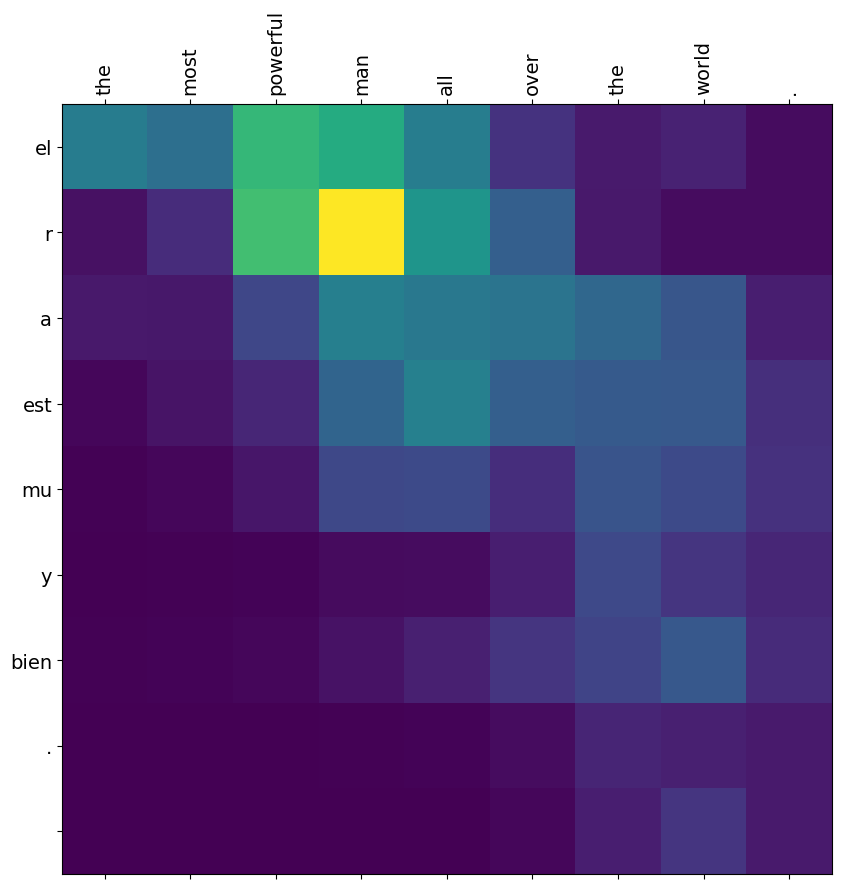

In [ ]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['pued', 'o', 'ayudar', 'os', '?', '']


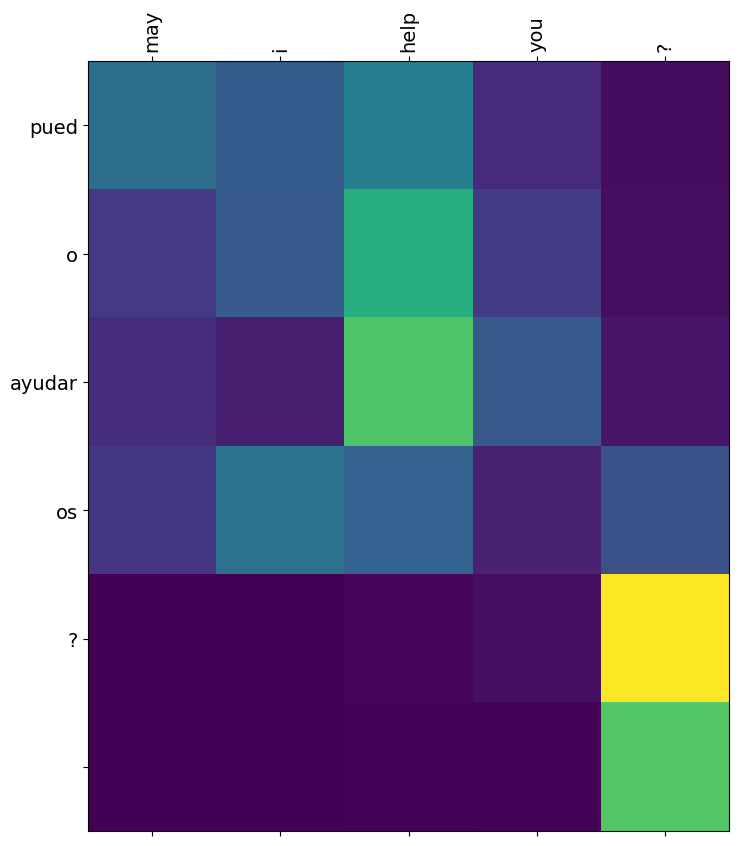

In [ ]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['pued', 'o', 'poco', 'el', 'c', 'af', '?', '']


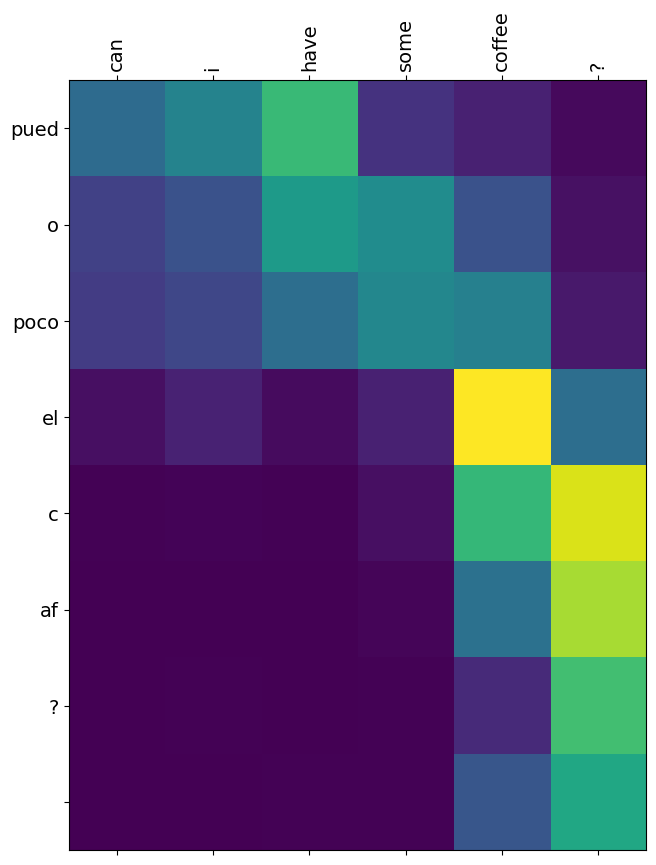

In [ ]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

### 3-4.4) 번역기 실행 (2)

- 중간 학습 멈춤으로 저장된 model_epoch1.pt 을 불러와 번역기 실행
- 중간 학습 멈추고 나서 런타임을 새로 실행하지 않아서 그런지 과접합이 더, 더, 더, 더 심해짐

Input: i gave her a card in the garden .
Predicted translation: ['agrade', 'inter', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi']
Predicted sentence:  agrade inter n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi


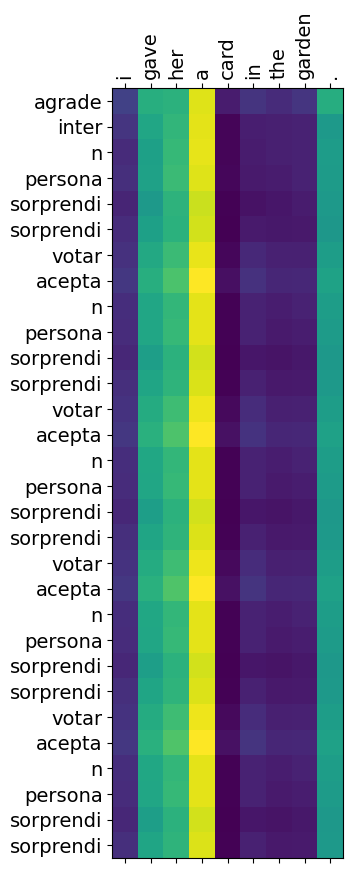

In [ ]:
translate("I gave her a card in the garden.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: the clouds are in the sky
Predicted translation: ['agrade', 'inter', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi']
Predicted sentence:  agrade inter n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi


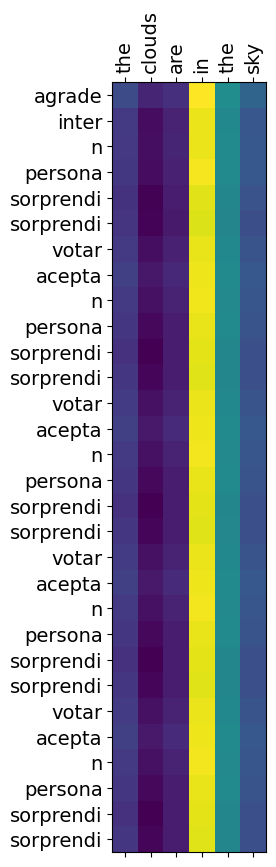

In [ ]:
translate("The clouds are in the sky", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: tom is a quiet student .
Predicted translation: ['agrade', 'inter', 'n', 'aprende', 'n', 'ambi', 'valor', 'valor', 'malo', 'valor', 'malo', 'valor', 'malo', 'seda', 'hoc', 'tuvier', 'valor', 'valor', 'malo', 'valor', 'malo', 'valor', 'malo', 'seda', 'hoc', 'tuvier', 'valor', 'valor', 'malo', 'valor']
Predicted sentence:  agrade inter n aprende n ambi valor valor malo valor malo valor malo seda hoc tuvier valor valor malo valor malo valor malo seda hoc tuvier valor valor malo valor


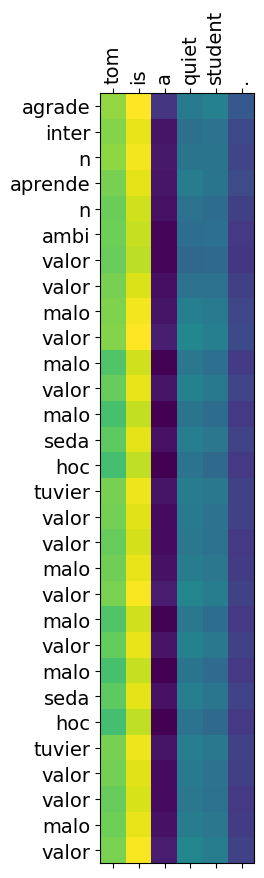

In [ ]:
translate("Tom is a quiet student.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: we saw a red bird
Predicted translation: ['agrade', 'inter', 'n', 'persona', 'malo', 'malo', 'seda', 'seda', 'boli', 'votar', 'n', 'aprende', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta']
Predicted sentence:  agrade inter n persona malo malo seda seda boli votar n aprende n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta


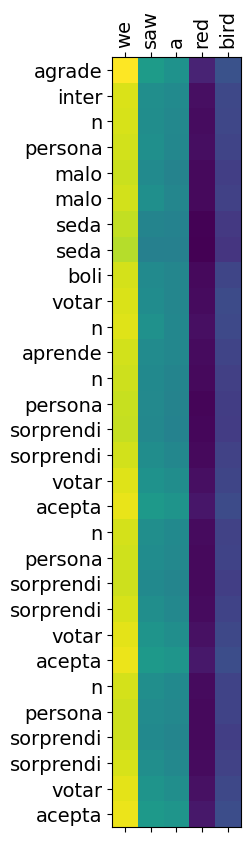

In [ ]:
translate("We saw a red bird", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: the most powerful man all over the world .
Predicted translation: ['agrade', 'inter', 'n', 'persona', 'malo', 'malo', 'seda', 'acebo', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta', 'n', 'persona', 'sorprendi', 'sorprendi', 'votar', 'acepta']
Predicted sentence:  agrade inter n persona malo malo seda acebo sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta


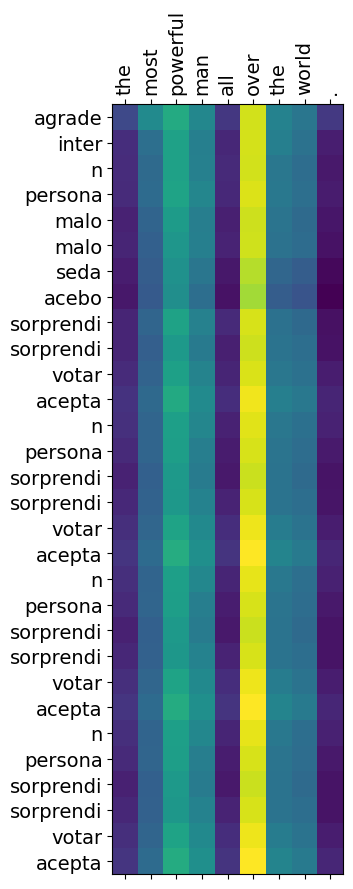

In [ ]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

### 3-4.4) 번역기 실행 (3)

- 런타임을 새로 실행하고 과적합 방지를 위해 epoch 횟수를 1/2로 줄여서 학습한 모델로 실행한 코드

Input: i gave her a card in the garden .
Predicted translation: ['le', 'di', 'una', 't', 'ar', 'a', 'a', 'lo', 's', 'pan', 'tal', 'ones', '.', '']
Predicted sentence:  le di una t ar a a lo s pan tal ones .


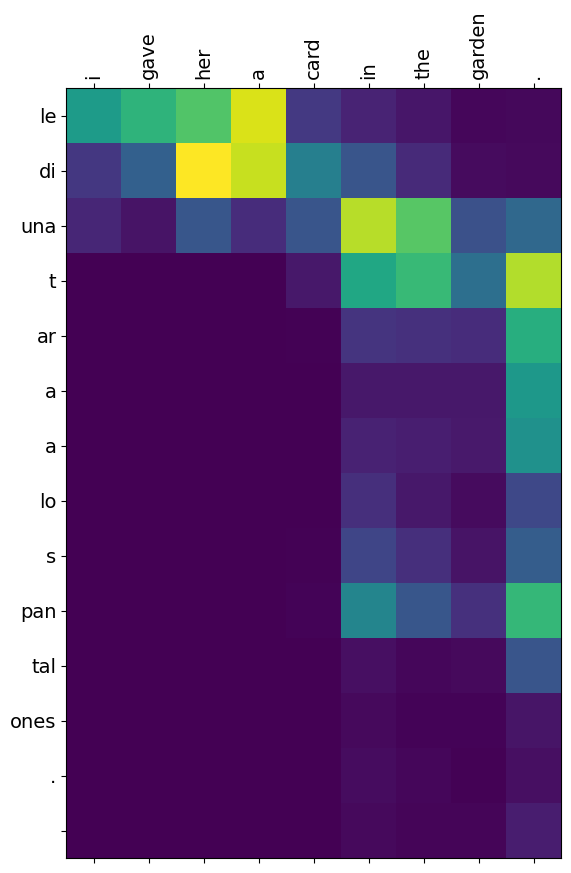

In [ ]:
translate("I gave her a card in the garden.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: the clouds are in the sky
Predicted translation: ['la', 'puerta', 'est', '', 'ida', '.', '']
Predicted sentence:  la puerta est ida .


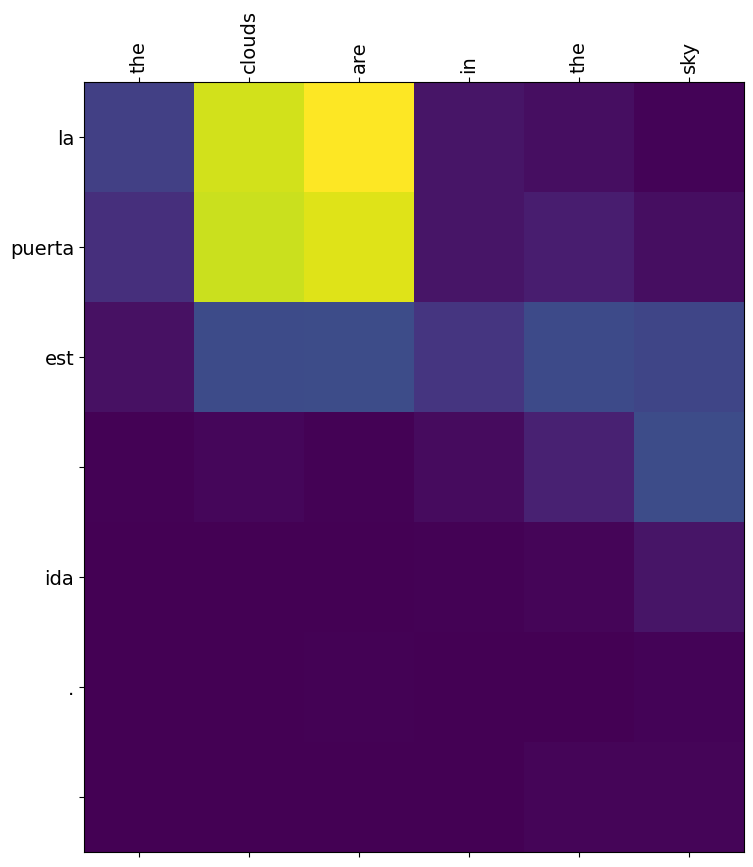

In [ ]:
translate("The clouds are in the sky", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: tom is a quiet student .
Predicted translation: ['tom', 'es', 'un', 'estudiante', '.', '']
Predicted sentence:  tom es un estudiante .


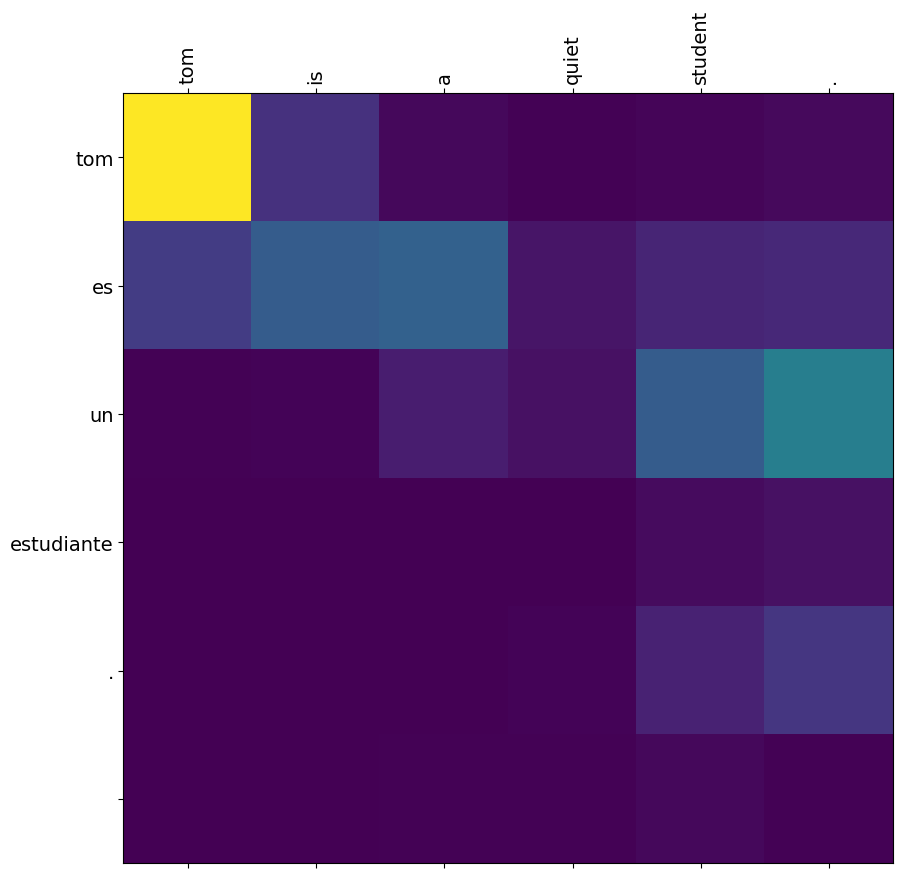

In [ ]:
translate("Tom is a quiet student.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: we saw a red bird
Predicted translation: ['vi', 'mos', 'un', 'p', 'jaro', '.', '']
Predicted sentence:  vi mos un p jaro .


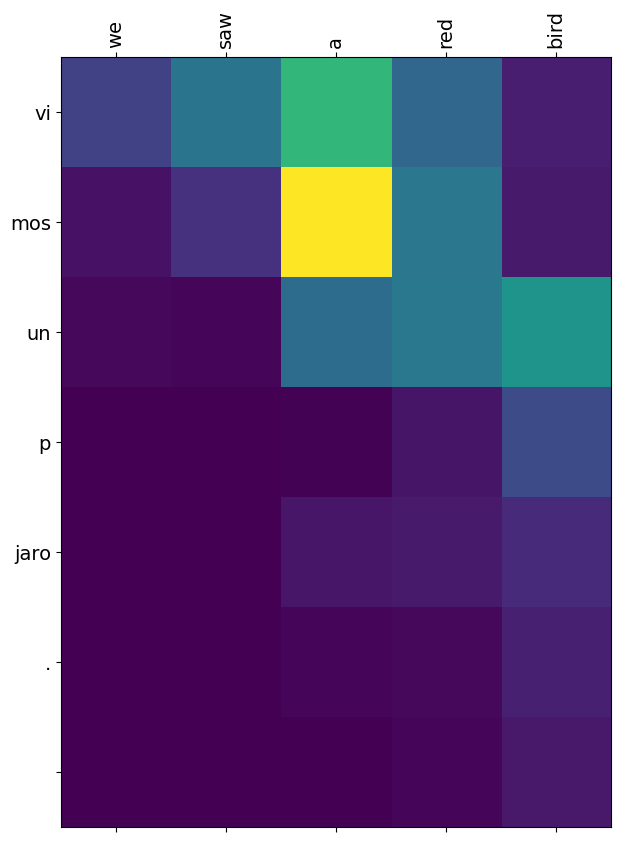

In [ ]:
translate("We saw a red bird", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: the most powerful man all over the world .
Predicted translation: ['el', 'contado', 'r', 'qu', 'a', 'toda', 'v', 'a', '.', '']
Predicted sentence:  el contado r qu a toda v a .


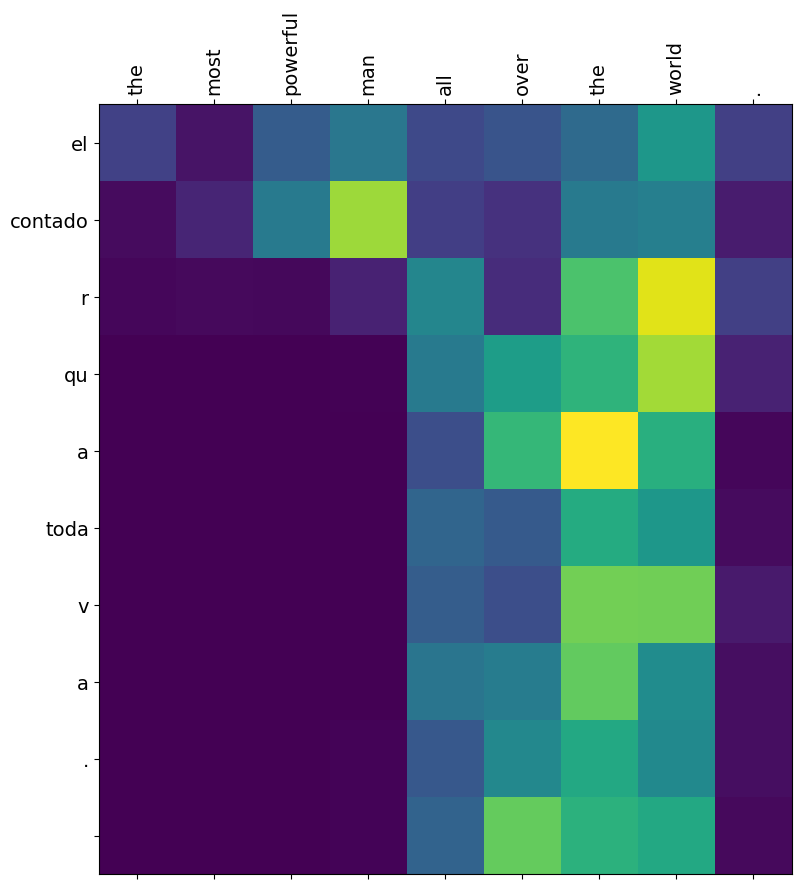

In [ ]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

# End.

## 번역기 내용을 다시 한글로 번역하면?
### 1회차
1. The most powerful man all over the world.  전 세계에서 가장 강력한 남자.
->el r a est mu y bien. 라가 아주 좋네요.
2. Can I have some coffee?  
--> pued o poco el c af? 커피 좀 마셔도 될까요?


### 2회차
1. I gave her a card in the garden. 정원에서 그녀에게 카드를 건넸어요.  
->  
agrade inter n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi votar acepta n persona sorprendi sorprendi.
감사합니다. n명이 놀랐습니다. 놀란 투표가 수락되었습니다. n명이 놀랐습니다. 놀란 투표가 수락되었습니다. n명이 놀랐습니다. 놀란 투표가 수락되었습니다. n명이 놀랐습니다. 놀란 투표가 수락되었습니다. n명이 놀랐습니다. 놀란 투표가 수락되었습니다. n명이 놀랐습니다. 놀란 투표가 수락되었습니다.
2. tom is a quiet student. 톰은 조용한 학생이에요  
->  agrade inter n aprende n ambi valor valor malo valor malo valor malo seda hoc tuvier valor valor malo valor malo valor malo seda hoc tuvier valor valor malo valor  
감사합니다 인터 앤 런 앤 앰비 가치 나쁜 가치 나쁜 가치 나쁜 가치 실크 혹 가치 나쁜 가치 나쁜 가치 나쁜 가치 실크 혹 가치 나쁜 가치 나쁜 가치 나쁜 가치
### 3회차
1. We saw a red bird  우리는 빨간 새를 보았다
-> vi mos un p jaro 너는 그때 한 살이 될 거야
2. The most powerful man all over the world 전 세계에서 가장 강력한 남자
->  el contado r qu a toda v a 회계사는 여전히
...

- 엉터리 번역이지만, 1,3회차는 그래도 번역된 내용을 구글번역기에 넣으면 스페인어라는 건 인식함.
- 2회차는 번역기 돌릴 필요 없이 문장길이가 너무 길고 단어 반복만 봐도 너무 심한 과적합
- 그나마 10 epoch에 학습을 중단한 1회차는 맞게 번역한 문장이 있음